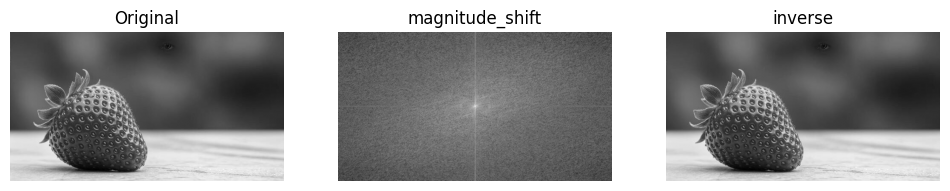

In [12]:
#1.
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('image.jpg',cv2.IMREAD_GRAYSCALE)
f_transform=np.fft.fft2(image)
f_shift=np.fft.fftshift(f_transform)
magnitude_shift=20*np.log(np.abs(f_shift)+1)
f_ishift=np.fft.ifftshift(f_shift)
img_back=np.fft.ifft2(f_shift)
img_back=np.abs(img_back)

plt.figure(figsize=(12,6))
plt.subplot(131),plt.imshow(image,cmap='gray')
plt.title('Original'),plt.axis('off')

plt.subplot(132),plt.imshow(magnitude_shift,cmap='gray')
plt.title('magnitude_shift'),plt.axis('off')

plt.subplot(133),plt.imshow(img_back,cmap='gray')
plt.title('inverse'),plt.axis('off')

plt.show()


C:\Users\Shrey\AppData\Local\Temp\ipykernel_30116\3492259891.py:23: RuntimeWarning: divide by zero encountered in divide
  'Butterworth_HP' : (1/(1+(D0/D+1e-6))**(2*n)),


<function matplotlib.pyplot.imshow(X: 'ArrayLike | PIL.Image.Image', cmap: 'str | Colormap | None' = None, norm: 'str | Normalize | None' = None, *, aspect: "Literal['equal', 'auto'] | float | None" = None, interpolation: 'str | None' = None, alpha: 'float | ArrayLike | None' = None, vmin: 'float | None' = None, vmax: 'float | None' = None, colorizer: 'Colorizer | None' = None, origin: "Literal['upper', 'lower'] | None" = None, extent: 'tuple[float, float, float, float] | None' = None, interpolation_stage: "Literal['data', 'rgba', 'auto'] | None" = None, filternorm: 'bool' = True, filterrad: 'float' = 4.0, resample: 'bool | None' = None, url: 'str | None' = None, data=None, **kwargs) -> 'AxesImage'>

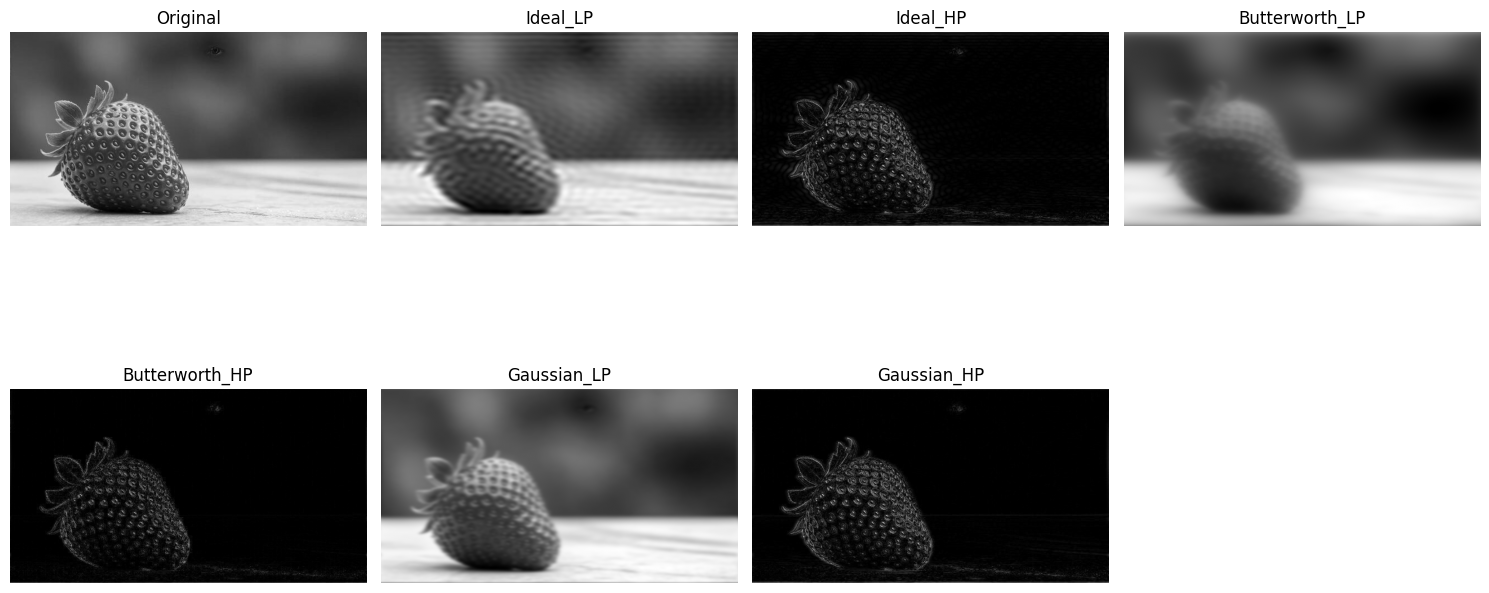

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('image.jpg',cv2.IMREAD_GRAYSCALE)
rows,cols=image.shape
cx,cy=rows//2 ,cols//2

F=np.fft.fftshift(np.fft.fft2(image))

x=np.arange(cols)-cy
y=np.arange(rows)-cx

X,Y=np.meshgrid(x,y)
D=np.sqrt(X**2+Y**2)

D0,n=30,2

filters={
    'Ideal_LP' : (D<=D0).astype(float),
    'Ideal_HP' : (D>D0).astype(float),
    'Butterworth_LP' : (1/(1+(D/D0))**(2*n)),
    'Butterworth_HP' : (1/(1+(D0/D+1e-6))**(2*n)),
    'Gaussian_LP' : np.exp(-D**2/(2*D0**2)),
    'Gaussian_HP' : 1-np.exp(-D**2/(2*D0**2)),
    
    }


plt.figure(figsize=(15,8))
plt.subplot(2,4,1)
plt.imshow(image,cmap='gray')
plt.title('Original'),plt.axis('off')

for i,(name,mask) in enumerate(filters.items(),start=2):
    filtered=np.abs(np.fft.ifft2(np.fft.ifftshift(F*mask)))
    plt.subplot(2,4,i)
    plt.imshow(filtered,cmap='gray')
    plt.title(name),plt.axis('off')
plt.tight_layout()
plt.imshow

(np.float64(-0.5), np.float64(9.5), np.float64(9.5), np.float64(-0.5))

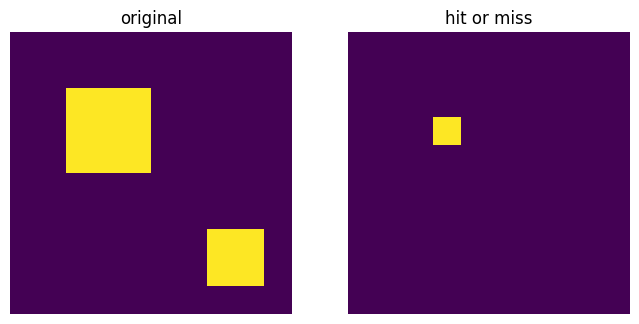

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import binary_hit_or_miss

image=np.zeros((10,10),dtype=int)
image[2:5, 2:5]=1
image[7:9, 7:9]=1
kernel=np.array([[1,1,1],
                 [1,1,1],
                 [1,1,1]])
result=binary_hit_or_miss(image,structure1=kernel)

plt.figure(figsize=(8,6))
plt.subplot(121)
plt.imshow(image)
plt.title('original')
plt.axis('off')
plt.subplot(122)
plt.imshow(result)
plt.title('hit or miss')
plt.axis('off')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_hit_or_miss

image=np.zeros((10,10),dtype=int)

image[2:5,2:5]=1
image[7:9,7:9]=1
kernel=np.array([[1,1,1],
                 [1,1,1],
                 [1,1,1]])
result=binary_hit_or_miss(image,structure1=kernel)
#plot

In [ ]:
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
import numpy as np

img=cv2.imread('image.jpg',0)

img=cv2.GaussianBlur(img, (5,5),1)

gx=cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)
gy=cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)

mag=np.sqrt(gx**2+gy**2)
mag=(mag/mag.max())*255

nms=np.where(mag==maximum_filter(mag,size=3),mag,0)

low,high=30,80
edges=np.zeros_like(nms)
edges[nms>=high]=255
edges[(nms<high)&(nms>=low)]=75

strong_neigbors=maximum_filter(edges==255,size=3)
edges[(edges==75)&~strong_neigbors]=0
edges[edges==75]==255

#plot



In [57]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def region_growing(image,seed,threshold):
    rows,cols=image.shape
    segmented=np.zeros((rows,cols),dtype=np.uint8)
    visited=np.zeros((rows,cols),dtype=bool)
    stack=[seed]
    seed_value=int(img[seed])
    visited[seed]=True
    while stack:
        y,x=stack.pop()
        for ny,nx in [(y-1,x),(y+1,x),(y,x-1),(y,x+1)]:
            if 0<=ny < rows and 0 <= nx <cols and not visited[ny,nx]:
                if abs(int(img[ny,nx])-seed_value)<=threshold:
                    visited[ny,nx]=True
                    stack.append((ny,nx))
    return segmented
image=cv2.imread('image.jpg',cv2.IMREAD_GRAYSCALE)
seed_point=(200,200)
threshold=30

result=region_growing(image,seed_point,threshold)
kernel=np.ones((5,5),np.uint8)

result=cv2.morphologyEx(result,cv2.MORPH_CLOSE,kernel)



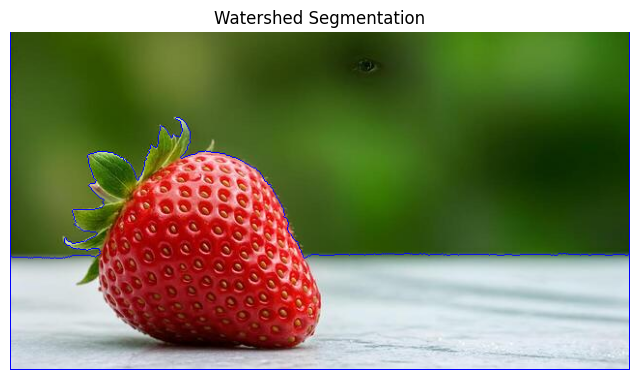

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def watershed_segmentation(image_path):
    img=cv2.imread(image_path)
    if img is None:
        print("error")
        return
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,thresh=cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel=np.ones((3,3),np.uint8)
    opening=cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel,iterations=3)
    sure_bg=cv2.dilate(opening,kernel,iterations=3)
    dist_transform=cv2.distanceTransform(opening,cv2.DIST_L2,5)
    _,sure_fg=cv2.threshold(dist_transform,0.7*dist_transform.max(),255,0)

    sure_fg=np.uint8(sure_fg)
    unknown=cv2.subtract(sure_bg,sure_fg)

    _,markers=cv2.connectedComponents(sure_fg)
    markers=markers+1
    markers[unknown==255]=0
    markers=cv2.watershed(img,markers)

    img[markers==-1]=[255,0,0]

    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Watershed Segmentation")
    plt.axis('off')
    plt.show()
if __name__ == "__main__":
    watershed_segmentation('image.jpg')   # change path if needed

